# 3. Preprocess + Window

EEGs dificilmente são gravações prontas para serem usadas em modelos. 

- **Sampling rate errado** - Cada aparelho grava em frequências diferentes (256Hz, 512Hz, etc). Redes neurais exigem entradas padronizadas, e taxas muito altas tornam o treino lento sem ganho real de informação (exige downsampling)
- **Drift and line noise** - O sinal capta oscilações lentas causadas por suor e movimentos e a interferência eletromagnética da rede elétrica local (ruído de 50Hz/60Hz).
- **No fixed reference** - O potencial de EEG é sempre medido em relação a outro ponto (mastoide, lóbulo da orelha ou média). Se gravações diferentes usam referências distintas, as amplitudes e padrões elétricos mudam.
- **Sporadic large-amplitude busrts (artefatos de grande amplitude esporádicos)** - Movimentos de olhos, mordidas, deglutição ou desconexão de eletrodos criam picos de voltagem muito maiores que a atividade cerebral real. Isso satura e desestabiliza os gradientes do modelo.
- **Continuous timeline instead of fixed epochs** - Redes neurais e tensores trabalham com matrizes de tamanho fixo. Uma gravação contínua e longa precisa ser fatiada em janelas menores e de tamanho idêntico.

Vamos aprender a pré-processar um dataset.

In [3]:
import matplotlib.pyplot as plt
import mne
import pandas as pd

import eegdash
from braindecode.preprocessing import (
    EEGPrep,
    Preprocessor,
    create_fixed_length_windows,
    preprocess,
)
from eegdash import EEGDashDataset
from eegdash.paths import get_default_cache_dir
from eegdash.viz import style_figure, use_eegdash_style

mne.viz.set_browser_backend("matplotlib")
mne.set_log_level("WARNING")
use_eegdash_style()

CACHE_DIR = get_default_cache_dir()
TARGET_SFREQ = 200.0  # Hz, see Step 5 (200 Hz keeps ASR's preferred rate)
WINDOW_SIZE_S = 2.0  # seconds, see Step 6
L_FREQ, H_FREQ = 1.0, 40.0  # band-pass edges in Hz
EEGPREP_SLICE_S = 30.0  # 30 s slice rendered in the diagnostic panel
print(f"eegdash {eegdash.__version__}; cache_dir={CACHE_DIR}")

/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:1452: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = make_standard_montage("standard_1

Using matplotlib as 2D backend.
eegdash 0.9.1; cache_dir=/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.eegdash_cache


## 3.1 Conceitos por trás do pré-processamento

1. **A ordem não é comutativa.**
    - Uma montagem atribui posições 3D aos canais, uma referência média é calculada entre esses canais e, portanto, a montagem precisa vir primeiro. 
    - A filtragem altera as amplitudes canal a canal, de modo que ela comuta com a referência, mas deve ser executada antes da reamostragem (caso contrário o novo Nyquist poderia cortar as bordas do passa-banda).
    - Windowing vem por último, de modo que o sinal fica dividido em frames de tamanho fixo.

## 3.2 Evidência do que ajuda e do que atrapalha

Kessler et al. (2025), *Communications Biology*, variou filtragem, referenciamenteo, baseline, diminuição de tendência e quatro estágios de correção de artefados entre sete experimentos ERP CORE (Event-Related Potential) (40 participantes) e decodificou com EEGNet e regressão logística time-resolved. 

- Todo passo de correção de artefato reduziu a performance de decodificação. 
- Filtros passa-altas (high-pass) com frequẽncias de corte mais altas aumentaram a performance. 
- Os autores alertam que artefatos não corrigidos podem elevar a acurácia ao custo da interpretabilidade (o modelo pode "trapacear" aprendendo padrões no próprio ruído em vez do sinal neural real).

Delorme (2023), *Scientific Reports*, mediu o compartilhamento de canais significantes em janelas de 100ms após estímulos entre três coleções públicas e comparou pipelines otimizados do EEGLAB, FIeldTrip, MNE e Brainstorm. 

- Apenas uma configuração superou o filtro passa-alta simples. 
- Remoção automatizada de artefatos musculares e oculares via ICA (Análise de Componentes Independentes) raramente ajudou.

Na prática: **Mantenha o pré-processamento curto e simples**. Ajuste com cuidado o filtro passa-alta.  Somente use ICA ou ASR após um protocolo de medida que mostra que eles realmente podem ajudar na *sua* downstream task.

## 3.3 Pré-Processando

### Passo 1: Carregando dataset

In [4]:
DATASET = "ds002718"
SUBJECT = "002"
TASK = "FaceRecognition"
CACHE_DIR = "./data"

dataset = EEGDashDataset(
    cache_dir=CACHE_DIR, dataset=DATASET, subject=SUBJECT, task=TASK
)
record = dataset.datasets[0]
raw = record.raw.load_data().copy()
raw

[09/13/26 13:38:54] INFO     Auto-corrected misrouted storage.base for dataset on002718:             ]8;id=6514754;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/dataset.py\dataset.py]8;;\:]8;id=6514755;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/dataset.py#561\561]8;;\
                             s3://nemar/on002718 -> s3://openneuro.org/ds002718                                    

<RawEEGLAB | sub-002_task-FaceRecognition_eeg.set, 74 x 747750 (2991.0 s), ~422.2 MiB, data loaded>

### Passo 2: Definindo a montagem

Uma montagem fala ao MNE onde os eletrodos estão em 3D. O sinal bruto traz apenas o nome dos canais e os valores de voltagem ao longo do tempo, mas não sabe a posição deles em 3D. Vamos definir as posições padrão 10-20.

O `set_montage` busca correspondências exatas de texto com os nomes anatômicos padronizados do sistema internacional (como Fp1, Fz, Cz, Oz, etc.).

`on_missing="ignore"` deixa sensores não-EEG (EOG, ref) intocados.

Se não houverem nomes na nomenclatura 10-20, o comando é inútil, e os canais terão de ser renomeados.

Para renomear (caso necessário):

In [5]:
# # Dicionário com o mapeamento real do seu equipamento/dataset
# channel_mapping = {
#     "EEG001": "Fp1",
#     "EEG002": "Fp2",
#     "EEG003": "F3",
#     "EEG004": "F4",
#     # ... adicione todos os seus canais correspondentes
# }

# # Renomeia os canais no objeto Raw
# raw.rename_channels(channel_mapping)

In [6]:
raw.set_montage("standard_1020", on_missing="ignore")
montage = raw.get_montage()
n_pos = len(montage.ch_names) if montage is not None else 0

print(f"montage attached: standard_1020 ({n_pos} channel positions)")

/tmp/ipykernel_141829/200336850.py:1: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  raw.set_montage("standard_1020", on_missing="ignore")


montage attached: standard_1020 (70 channel positions)


### Passo 3: Definindo uma referência média

Toda voltagem em EEG é uma diferença de potencial. A escolha de referência provoca um shift em toda amostra. Uma referência-média comum  (CAR) é subtrair a média de todos os eletrodos a cada ponto (instante).

$$ \hat{V_i}(t) = V_i(t) - \frac{1}{N} \sum_{k=1}^{N} V_k(t) $$

Isso remove ruídos globais compartilhados igualmente por todos os canais e é uma escolha padrão quando há cobertura da cabeça inteira.

`projection=False` Aplica isso imediatamente.

In [7]:
raw.set_eeg_reference("average", projection=False)

print(f"custom_ref_applied={raw.info['custom_ref_applied']}")

custom_ref_applied=1 (FIFFV_MNE_CUSTOM_REF_ON)


### Passo 4: Band-Pass Filter (1-40Hz, FIR, Zero-Phase)

Um filtro FIR com janela de Hamming `firwin` é o padrão reprodutível do MNE de filtro digital para garantir estabilidade numérica e não distorcer o alinhamento temporal dos sinais.

Um filtro passa-banda 1-40Hz remove drift (oscilação muito lenta e contínua no sinal) abaixo de 1Hz e atenua ruído de linha acima de 40Hz. 

O passa-alta de 1Hz não é uma escolha. Tanto Kessler et al. (2025) quanto Delorme (2023) reportaram que elevar esse corte é o pré-processamento com o maior efeito positivo na performance de downstream tasks. Tente definir `L_FREQ = 0.5` e `L_FREQ = 1.5` para comparar.

Vamos ver o PSD antes do processamento.

/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/viz/identity.py:178: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.84, bottom=0.18, left=0.12, right=0.95)


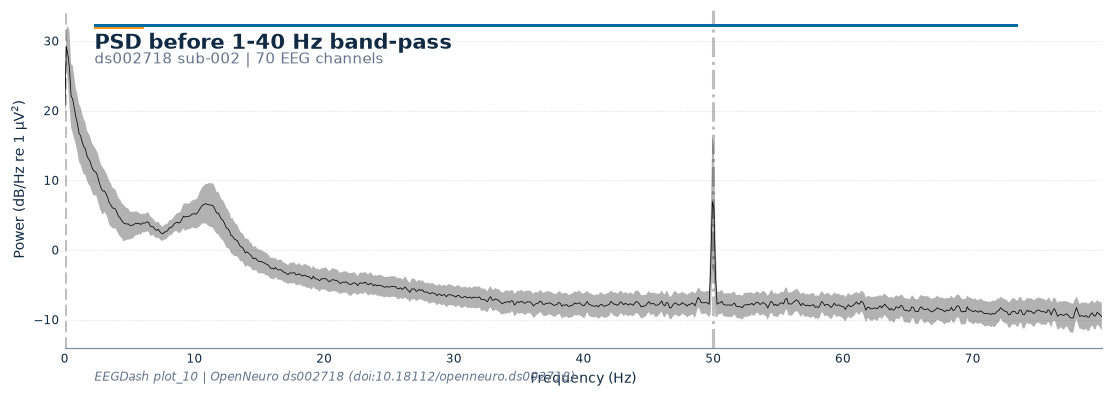

In [8]:
# Antes do processamento
raw_before = record.raw.load_data().copy()
psd = raw_before.copy().pick("eeg").compute_psd(fmax=80.0, verbose=False)
fig_psd = psd.plot(picks="eeg", average=True, show=False)
style_figure(
    fig_psd,
    title="PSD before 1-40 Hz band-pass",
    subtitle=(
        f"{DATASET} sub-{SUBJECT} | {len(raw.copy().pick('eeg').ch_names)} EEG channels"
    ),
    source=(f"EEGDash plot_10 | OpenNeuro {DATASET} (doi:10.18112/openneuro.ds002718)"),
)
plt.show()

Agora, vamos aplicar o filtro passa-banda e ver o novo PSD.

In [9]:
L_FREQ = 1
H_FREQ = 40

raw.filter(
    l_freq=L_FREQ,       # Frequência passa-baixa
    h_freq=H_FREQ,       # Frequência passa-alta
    method="fir",
    fir_design="firwin", 
    phase="zero",        # Filtragem sem deslocar picos das ondes no tempo (atraso de fase)
    verbose=False,
)
print(f"highpass={raw.info['highpass']:.2f} Hz, lowpass={raw.info['lowpass']:.2f} Hz")

highpass=1.00 Hz, lowpass=40.00 Hz


/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/viz/identity.py:178: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.84, bottom=0.18, left=0.12, right=0.95)


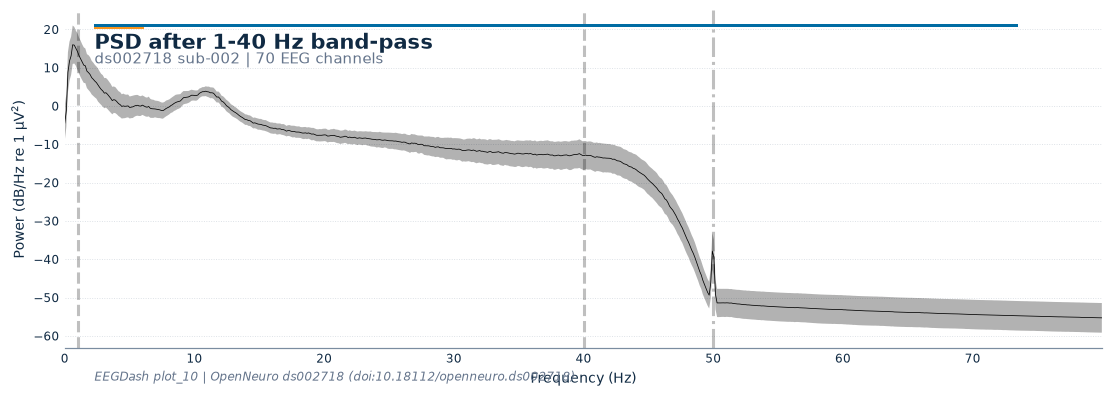

In [10]:
# Depois do processamento
psd = raw.copy().pick("eeg").compute_psd(fmax=80.0, verbose=False)
fig_psd = psd.plot(picks="eeg", average=True, show=False)
style_figure(
    fig_psd,
    title="PSD after 1-40 Hz band-pass",
    subtitle=(
        f"{DATASET} sub-{SUBJECT} | {len(raw.copy().pick('eeg').ch_names)} EEG channels"
    ),
    source=(f"EEGDash plot_10 | OpenNeuro {DATASET} (doi:10.18112/openneuro.ds002718)"),
)
plt.show()

### Passo 5: Resampling para 200Hz

O sampling rate original está muito acima do que um conteúdo 1-40Hz precisa. 200Hz mantém uma distância confortável de Nyquist (se usamos 200Hz, a frequẽncia de Nyquist, frequência máxima teórica que o sinal digitalizado consegue registrar sem distorção, é a metade, 100Hz).

Um downsampling para 200Hz também provoca uma economia massiva de memória RAM e acelera o treinamento, ao dividir a quantidade de pontos temporais, e fica dentro do conjunto de frequências para o qual o ASR é calibrado (100, 128, 200, 250, 256, 300, 500, 512 Hz).

In [11]:
TARGET_SFREQ = 200

sfreq_before = raw.info["sfreq"]
shape_before = raw.get_data().shape

raw.resample(TARGET_SFREQ, verbose=False)

print(f"sfreq: {sfreq_before:.1f} Hz -> {raw.info['sfreq']:.1f} Hz")
print(f"raw.get_data().shape: {shape_before} -> {raw.get_data().shape}")

sfreq: 250.0 Hz -> 200.0 Hz
raw.get_data().shape: (74, 747750) -> (74, 598200)


### Passo Final: Aplicar a mesma receita para o dataset inteiro (e criar janelas)

In [12]:
WINDOW_SIZE_S = 2 # Segundos
WINDOW_SAMPLES = int(WINDOW_SIZE_S * TARGET_SFREQ)

preprocess(
    dataset,
    [
        # Definir montagem standard 10-20
        Preprocessor("set_montage", montage="standard_1020", on_missing="ignore"),
        # Definir referência-média comum (CAR)
        Preprocessor("set_eeg_reference", ref_channels="average"),
        # Filtro band-pass (1-40Hz)
        Preprocessor(
            "filter",
            l_freq=L_FREQ,
            h_freq=H_FREQ,
            method="fir",
            fir_design="firwin",
        ),
        # Downsampling
        Preprocessor("resample", sfreq=TARGET_SFREQ),
    ],
)
# Criação das janelas
windows = create_fixed_length_windows(
    dataset,
    window_size_samples=WINDOW_SAMPLES,
    window_stride_samples=WINDOW_SAMPLES,
    drop_last_window=True,
)
x0, _, _ = windows[0]

# Mostrar informações
pd.DataFrame(
    {
        "value": [
            len(windows),
            f"{x0.shape}",
            str(x0.dtype),
            int(TARGET_SFREQ),
            WINDOW_SAMPLES,
        ]
    },
    index=["n_windows", "windows[0][0].shape", "dtype", "sfreq (Hz)", "window_samples"],
)

/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/preprocess.py:120: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  return getattr(raw_or_epochs, fn)(**kwargs)
/tmp/ipykernel_141829/842282629.py:24: DeprecationWarning: `drop_last_window` is deprecated and will be removed in version 2.0. Use `on_last_window='drop'` if True or `on_last_window='overlap'` if False. See https://github.com/braindecode/braindecode/pull/1058 for feedback.
  windows = create_fixed_length_windows(


,value
n_windows,1495
windows[0][0].shape,"(74, 400)"
dtype,float32
sfreq (Hz),200
window_samples,400


### Extra: EEGPrep

A classe EEGPrep é uma ferramenta automatizada de limpeza de dados EEG, onde apenas definimos os hiperparâmetros.

In [13]:
record_pp = EEGDashDataset(
    cache_dir=CACHE_DIR, dataset=DATASET, subject=SUBJECT, task=TASK
).datasets[0]
raw_full = record_pp.raw.load_data().copy()

EEGPREP_SLICE_S = 30 # Segundos

# Define montagem standard 10-20
raw_full.set_montage("standard_1020", on_missing="ignore")
# Recorta o sinal nos primeiros segundos para testes rápidos
raw_pp = raw_full.copy().crop(0.0, min(EEGPREP_SLICE_S, raw_full.times[-1]))
# Salva uma cópia isolando apenas os canais de EEG
raw_before = raw_pp.copy().pick("eeg")

eegprep = EEGPrep(
    resample_to=TARGET_SFREQ,             # Resampling
    highpass_frequencies=(0.25, 0.75),    # Filtro passa-alta com banda de transição 0.25-0.75 Hz
    bad_channel_corr_threshold=0.8,       # Descarta canais com correlação abaixo de 0.8 com canais vizinhos (eletrodos sem sinal ou com ruído descorrelacionado)
    burst_removal_cutoff=10.0,            # Limiar estatístico de std do ASR para reparar artefatos
    bad_window_max_bad_channels=0.25,     # Marca trechos temporais ruins se mais de 25% dos canais forem corrompidos
    bad_channel_reinterpolate=False,      # Não reconstrói os canais descartados (por interpolação)
    common_avg_ref=True,                  # Aplica CAR
)
eegprep.fn(raw_pp)  # Aplica pré-processamento
raw_after = raw_pp

n_dropped = len(raw_before.ch_names) - len(raw_after.copy().pick("eeg").ch_names)
n_bad_annot = sum(1 for a in raw_after.annotations if "BAD" in a["description"].upper())

[09/13/26 13:39:22] INFO     Auto-corrected misrouted storage.base for dataset on002718:             ]8;id=6514760;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/dataset.py\dataset.py]8;;\:]8;id=6514761;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/dataset.py#561\561]8;;\
                             s3://nemar/on002718 -> s3://openneuro.org/ds002718                                    

/tmp/ipykernel_141829/2724801623.py:9: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  raw_full.set_montage("standard_1020", on_missing="ignore")


[09/13/26 13:39:27] INFO     eeg_checkset: xmax adjusted to match pnts, xmin, and srate         ]8;id=6514768;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py\eeg_checkset.py]8;;\:]8;id=6514769;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/adminfunc/eeg_checkset.py#436\436]8;;\

                    INFO     resampling data 200 Hz                                             ]8;id=6514776;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/popfunc/pop_resample.py\pop_resample.py]8;;\:]8;id=6514777;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/popfunc/pop_resample.py#167\167]8;;\

                    INFO     resampling channel data segment 1 of 1                             ]8;id=6514783;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/popfunc/pop_resample.py\pop_resample.py]8;;\:]8;id=6514784;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/functions/popfunc/pop_resample.py#182\182]8;;\

...

                    INFO     Determining time window rejection thresholds...                   ]8;id=6514942;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_windows.py\clean_windows.py]8;;\:]8;id=6514943;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_windows.py#121\121]8;;\

[09/13/26 13:39:37] INFO     done.                                                             ]8;id=6514948;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_windows.py\clean_windows.py]8;;\:]8;id=6514949;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_windows.py#153\153]8;;\

                    INFO     Keeping 100.0% (30 seconds) of the data.                          ]8;id=6514954;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_windows.py\clean_windows.py]8;;\:]8;id=6514955;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_windows.py#185\185]8;;\

                    INFO     Use vis_artifacts to compare the cleaned data to the original.  ]8;id=6514961;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_artifacts.py\clean_artifacts.py]8;;\:]8;id=6514962;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegprep/plugins/clean_rawdata/clean_artifacts.py#307\307]8;;\

                    ERROR    Could not add back non-EEG channels (EEG061, EEG062, EEG063, ]8;id=6514969;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py\eegprep_preprocess.py]8;;\:]8;id=6514970;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/preprocessing/eegprep_preprocess.py#231\231]8;;\
                             EEG064) after EEGPrep processing; these will be omitted from                          
                             the processed data. If you want to retain these channels,                             
                             you will have to disable resample and bad time window                                 
                             removal in the EEGPrep Preprocessor; you may perform that                             
                             step using other methods before and after EEGPrep,                                    
                             respectively.                                                                         